# Movie Ratings Bias Analysis

## Project overview

This project investigates whether **Fandango movie ratings appeared systematically inflated in 2015** when compared with other popular review platforms.

### Business question
If a platform both **displays ratings** and **sells movie tickets**, can its incentives affect how ratings are presented to users?

### What this notebook demonstrates
- exploratory data analysis with **pandas**
- visual storytelling with **matplotlib** and **seaborn**
- comparison of rating systems across multiple platforms
- normalization of different scoring scales to a common **0–5 range**
- interpretation of patterns and possible business implications

### Tools
`Python`, `pandas`, `NumPy`, `matplotlib`, `seaborn`

## Data sources

The analysis uses two CSV files from the original FiveThirtyEight movie ratings investigation:

- **`fandango_scrape.csv`** — Fandango ratings, displayed stars, and vote counts
- **`all_sites_scores.csv`** — ratings from Rotten Tomatoes, Metacritic, IMDb, and related vote counts

The goal is not to prove causation, but to evaluate whether the observed patterns are **consistent with rating inflation**.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## 2. Load the data

In [2]:
fandango = pd.read_csv("fandango_scrape.csv")

In [3]:
all_sites = pd.read_csv("all_sites_scores.csv")

## 3. Fandango ratings and vote behavior

First, I examine the relationship between **Fandango's displayed rating** and the **number of user votes** attached to each film.

<AxesSubplot:xlabel='RATING', ylabel='VOTES'>

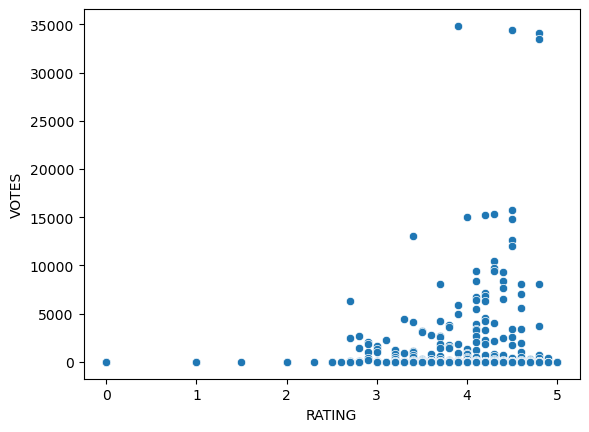

In [4]:
sns.scatterplot(data=fandango, x='RATING', y='VOTES')

**Observation:** ratings cluster heavily in the upper range, while vote counts vary widely.  
This already suggests that high displayed scores are common on Fandango, even before cross-platform comparison.

In [5]:
fandango["YEAR"] = fandango["FILM"].str.extract(r"\((\d+)\)")
fandango["YEAR"]

0      2015
1      2015
2      2015
3      2015
4      2015
       ... 
499    2015
500    2015
501    2015
502    1964
503    2012
Name: YEAR, Length: 504, dtype: object

<AxesSubplot:xlabel='YEAR', ylabel='count'>

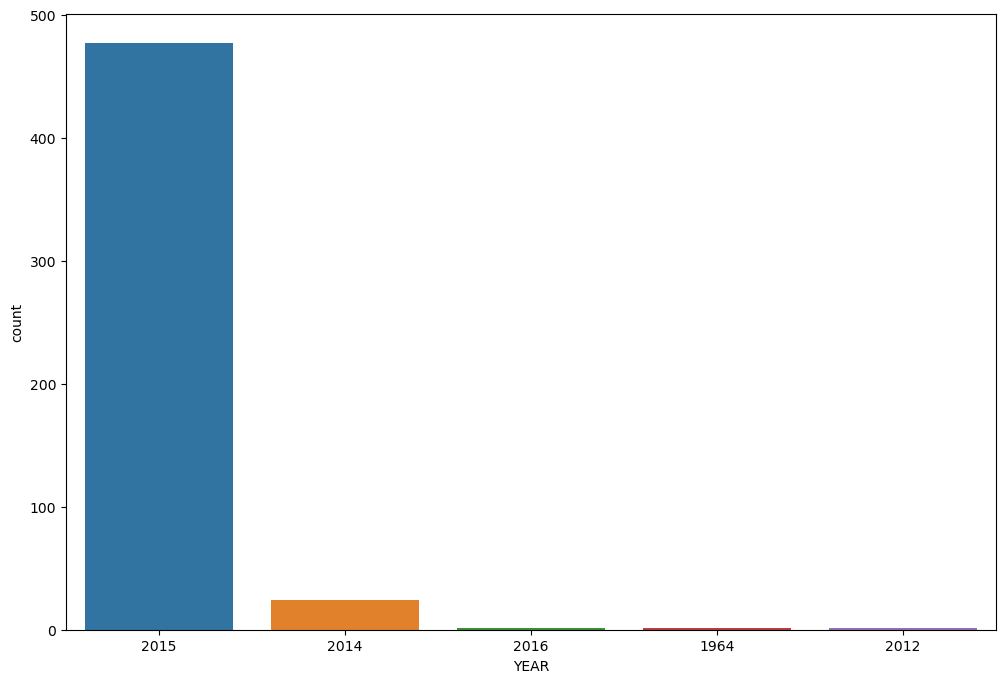

In [6]:
fig = plt.figure(figsize=(12, 8))
sns.countplot(data=fandango, x="YEAR")
plt.title("Film count by year in the Fandango dataset")
plt.show()

In [7]:
(fandango["VOTES"] == 0).sum()

69

There are **69 movies with zero recorded votes**.  
That matters because a displayed rating can look persuasive even when there is little or no visible voting activity behind it.

In [8]:
films_with_votes = fandango[fandango['VOTES'] != 0].copy()

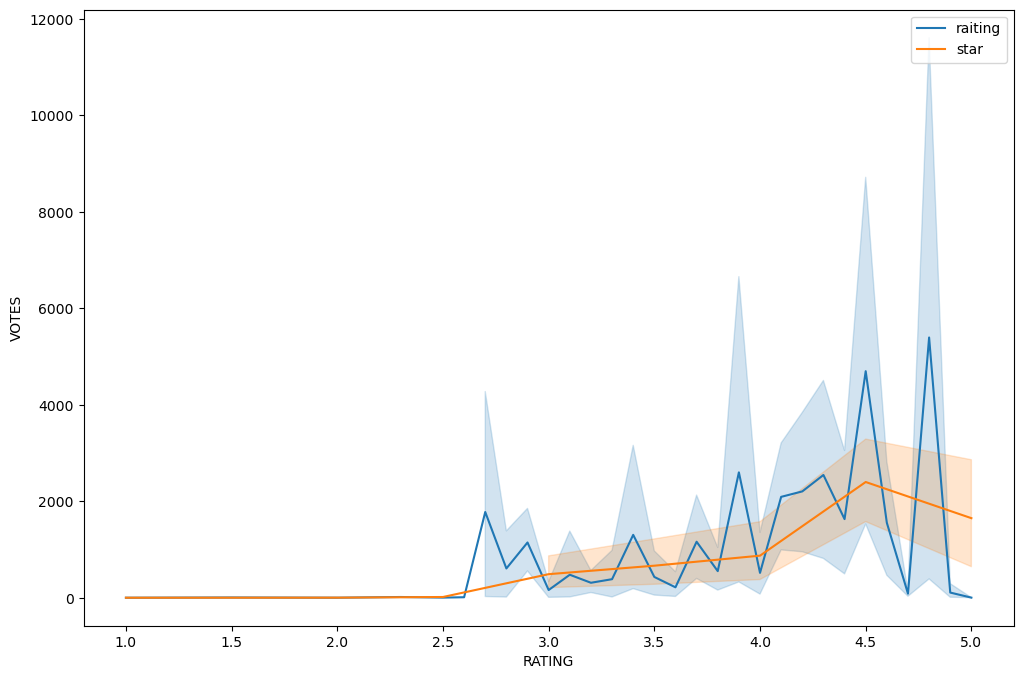

In [9]:
plt.figure(figsize=(12, 8))
sns.lineplot(data=films_with_votes, x="RATING", y="VOTES", label="Numeric rating")
sns.lineplot(data=films_with_votes, x="STARS", y="VOTES", label="Displayed stars")
plt.legend()
plt.title("Displayed stars vs. numeric rating")
plt.show()

In [10]:
films_with_votes['STARS_DIFF'] = (films_with_votes['STARS'] - films_with_votes['RATING']).round(1)
films_with_votes

,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
0,Fifty Shades of Grey (2015),4.0,3.9,34846,2015,0.1
1,Jurassic World (2015),4.5,4.5,34390,2015,0.0
2,American Sniper (2015),5.0,4.8,34085,2015,0.2
3,Furious 7 (2015),5.0,4.8,33538,2015,0.2
4,Inside Out (2015),4.5,4.5,15749,2015,0.0
...,...,...,...,...,...,...
430,That Sugar Film (2015),5.0,5.0,1,2015,0.0
431,The Intern (2015),5.0,5.0,1,2015,0.0
432,The Park Bench (2015),5.0,5.0,1,2015,0.0
433,The Wanted 18 (2015),5.0,5.0,1,2015,0.0


<AxesSubplot:xlabel='STARS_DIFF', ylabel='count'>

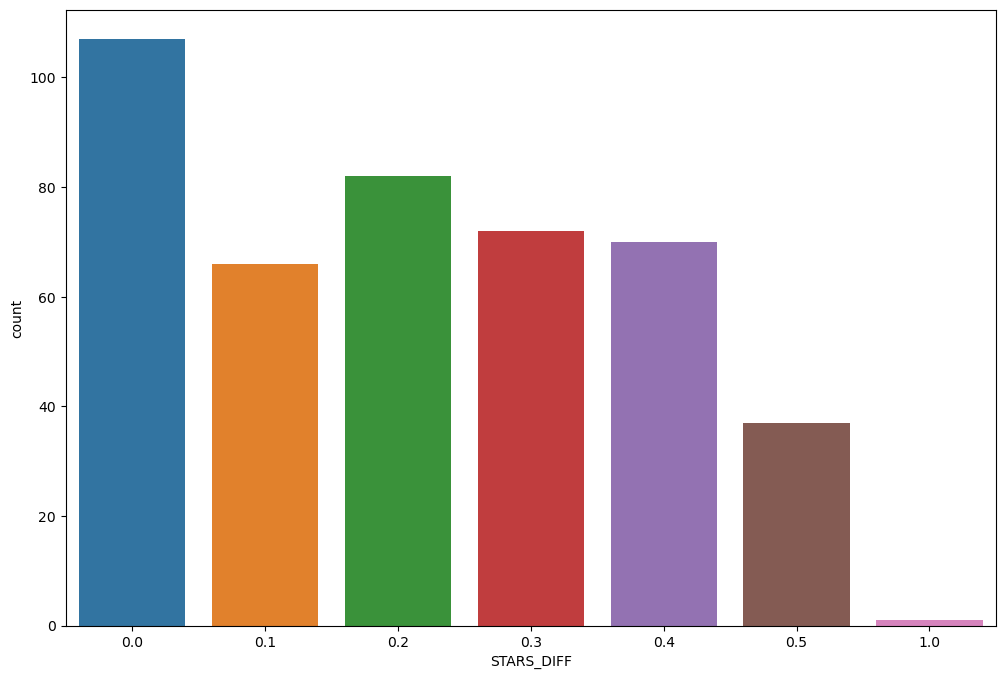

In [11]:
plt.figure(figsize=(12,8))
sns.countplot(data=films_with_votes, x='STARS_DIFF')

In [12]:
films_with_votes[films_with_votes['STARS_DIFF'] == 1]

,FILM,STARS,RATING,VOTES,YEAR,STARS_DIFF
381,Turbo Kid (2015),5.0,4.0,2,2015,1.0


The **star display is often rounded upward** relative to the numeric rating.  
This presentation effect is important: even when the underlying rating is lower, the visual star score may make a movie appear better at a glance.

## 4. Rotten Tomatoes: critics vs. users

Before comparing Fandango to other platforms, I check how **critic** and **user** scores differ within Rotten Tomatoes itself.

<AxesSubplot:xlabel='RottenTomatoes', ylabel='RottenTomatoes_User'>

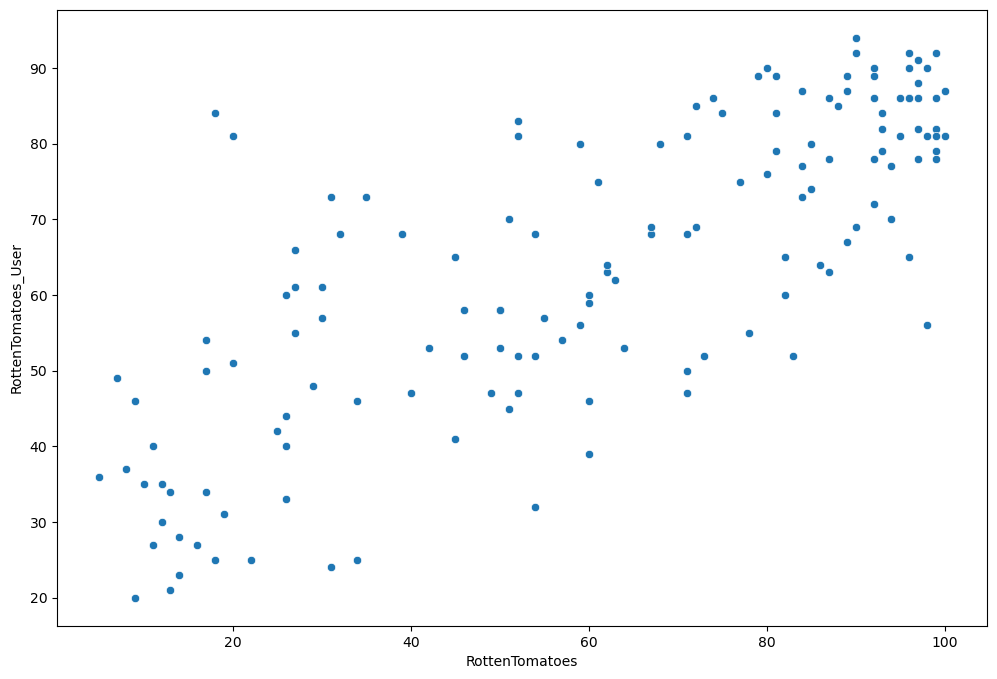

In [13]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=all_sites, x='RottenTomatoes', y='RottenTomatoes_User')

In [14]:
all_sites['tomato_diff'] = all_sites['RottenTomatoes'] - all_sites['RottenTomatoes_User']

In [15]:
all_sites['tomato_diff'].abs().mean()

15.095890410958905

<AxesSubplot:xlabel='tomato_diff', ylabel='Count'>

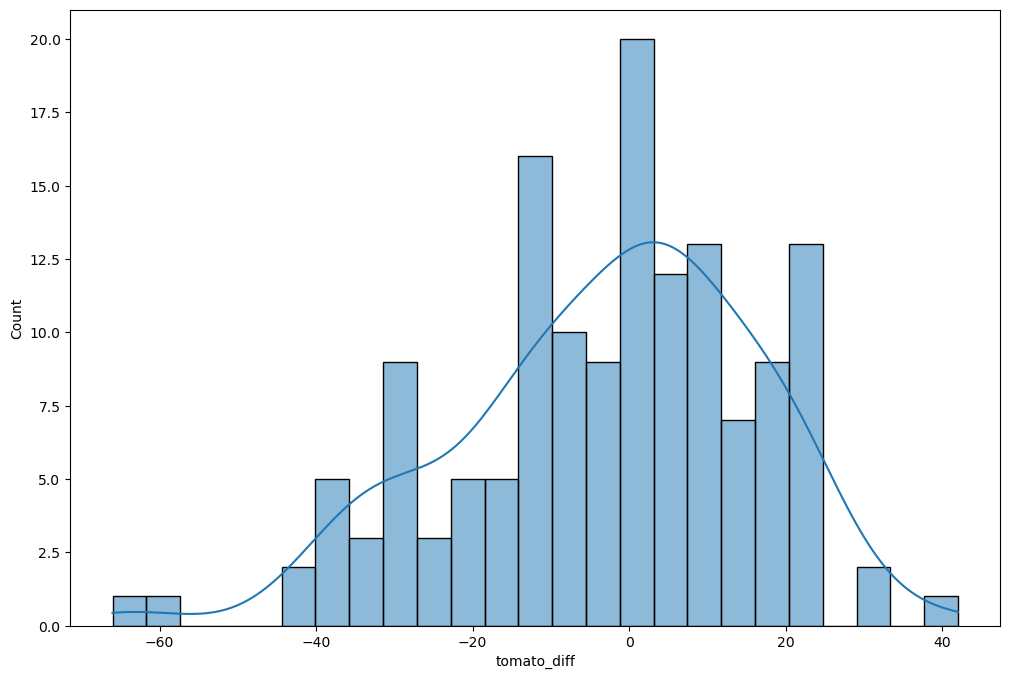

In [16]:
plt.figure(figsize=(12,8))
sns.histplot(data=all_sites, x='tomato_diff', bins=25, kde=True)

<AxesSubplot:xlabel='tomato_diff', ylabel='Count'>

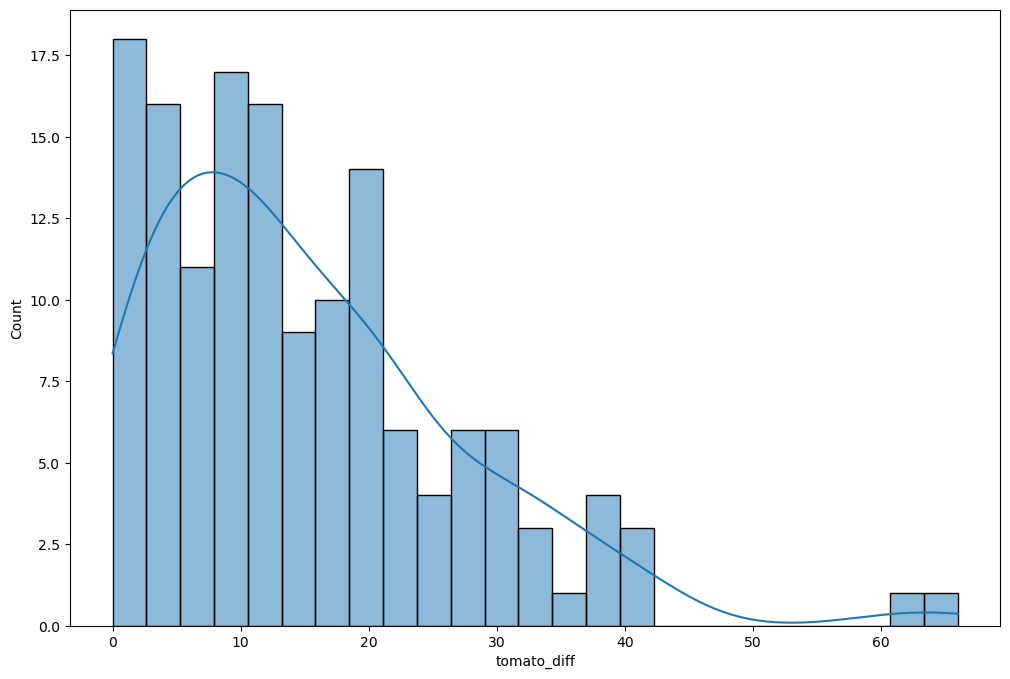

In [17]:
plt.figure(figsize=(12,8))
sns.histplot(data=all_sites, x=all_sites['tomato_diff'].abs(), bins=25, kde=True)

In [18]:
all_sites.sort_values('tomato_diff')[['FILM', 'tomato_diff']][:5]

,FILM,tomato_diff
3,Do You Believe? (2015),-66
85,Little Boy (2015),-61
134,The Longest Ride (2015),-42
105,Hitman: Agent 47 (2015),-42
125,The Wedding Ringer (2015),-39


In [19]:
all_sites.sort_values('tomato_diff', ascending=False)[['FILM', 'tomato_diff']][:5]

,FILM,tomato_diff
69,Mr. Turner (2014),42
112,It Follows (2015),31
115,While We're Young (2015),31
145,"Kumiko, The Treasure Hunter (2015)",24
37,Welcome to Me (2015),24


The average absolute gap between Rotten Tomatoes critic and user scores is about **15 points**.  
This confirms that disagreement between platforms or audiences is normal — which makes normalization and cross-platform comparison especially important.

## 5. Additional context: Metacritic and IMDb

<AxesSubplot:xlabel='Metacritic', ylabel='Metacritic_User'>

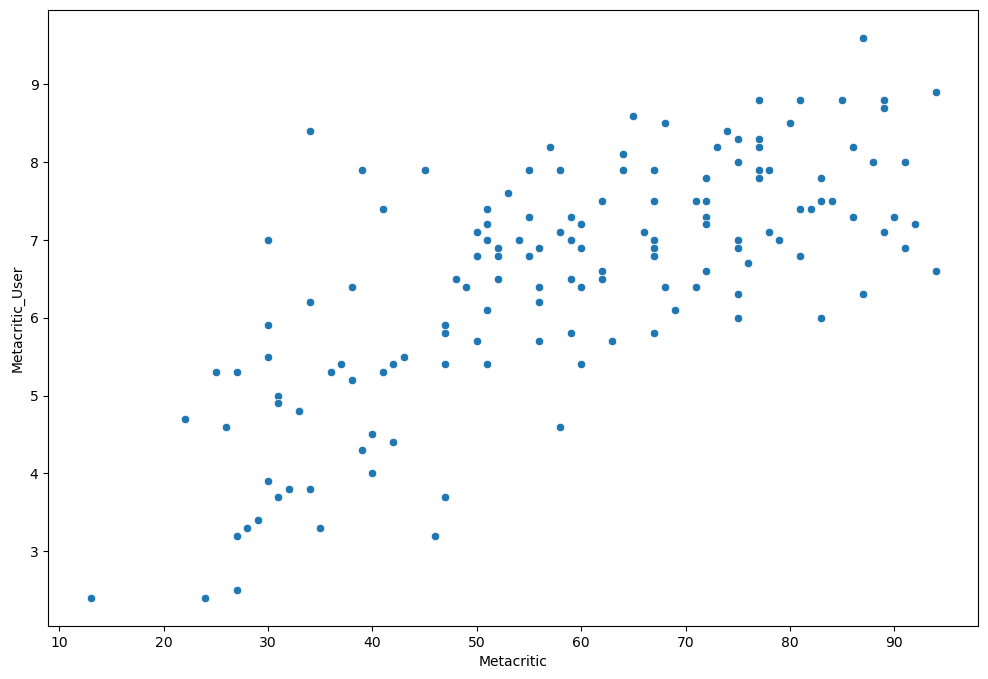

In [20]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=all_sites, x='Metacritic', y='Metacritic_User')

In [21]:
all_sites.sort_values('IMDB_user_vote_count', ascending=False)[:1]

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,tomato_diff
14,The Imitation Game (2014),90,92,73,8.2,8.1,566,334164,-2


Metacritic also shows visible disagreement between critic and user scores.  
IMDb provides an additional large-sample user benchmark, which is useful when comparing Fandango to broader audience sentiment.

## 6. Merge datasets and normalize rating scales

Because each platform uses a different scale, I convert everything to a shared **0–5 scale** before comparing distributions.

In [22]:
films = fandango.merge(all_sites, how='inner', on='FILM')

In [23]:
films.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 145 entries, 0 to 144
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        145 non-null    object 
 1   STARS                       145 non-null    float64
 2   RATING                      145 non-null    float64
 3   VOTES                       145 non-null    int64  
 4   YEAR                        145 non-null    object 
 5   RottenTomatoes              145 non-null    int64  
 6   RottenTomatoes_User         145 non-null    int64  
 7   Metacritic                  145 non-null    int64  
 8   Metacritic_User             145 non-null    float64
 9   IMDB                        145 non-null    float64
 10  Metacritic_user_vote_count  145 non-null    int64  
 11  IMDB_user_vote_count        145 non-null    int64  
 12  tomato_diff                 145 non-null    int64  
dtypes: float64(4), int64(7), object(2)


In [24]:
films['RT_Norm'] = (films['RottenTomatoes'] / 20).round(1)
films['RTU_Norm'] = (films['RottenTomatoes_User'] / 20).round(1)

In [25]:
films['MC_Norm'] = (films['Metacritic'] / 20).round(1)
films['MCU_Norm'] = (films['Metacritic_User'] / 2).round(1)

In [26]:
films['IMDB_Norm'] = (films['IMDB'] / 2).round(1)

In [27]:
norm_scores = films[["STARS", "RATING", "RT_Norm", "RTU_Norm", "MC_Norm", "MCU_Norm", "IMDB_Norm"]]

In [28]:
norm_scores.head()

,STARS,RATING,RT_Norm,RTU_Norm,MC_Norm,MCU_Norm,IMDB_Norm
0,4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,4.5,4.5,4.9,4.5,4.7,4.4,4.3


After merging, the analysis contains **145 overlapping films** across platforms.  
This gives a clean subset for comparing how the same movies were scored in different ecosystems.

## 7. Compare normalized rating distributions

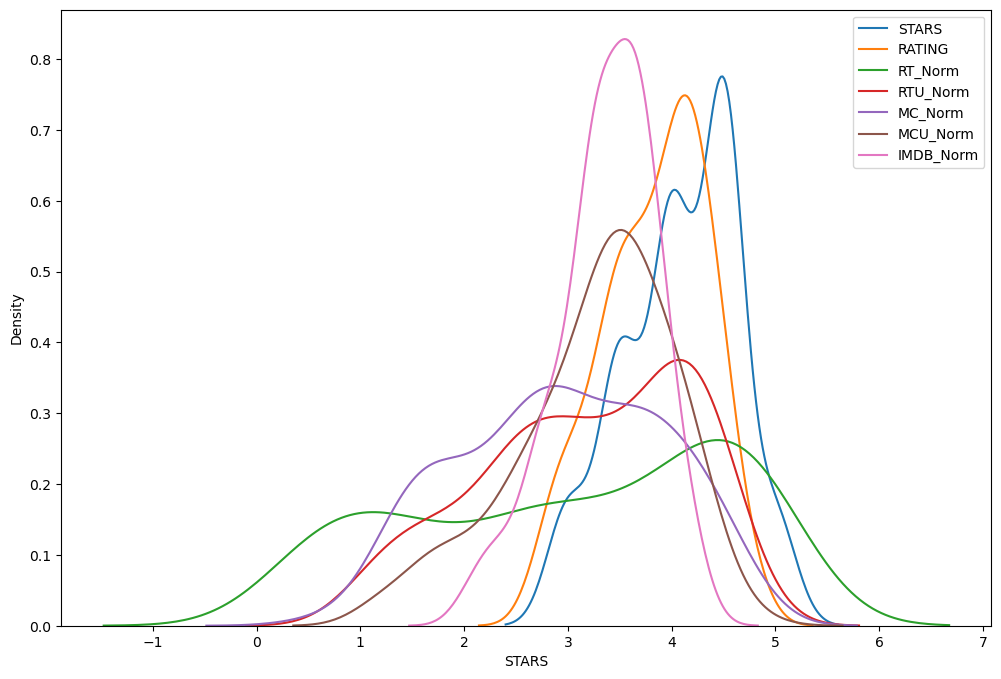

In [29]:
plt.figure(figsize=(12, 8))
for col in norm_scores.columns:
    sns.kdeplot(norm_scores[col], label=col)
    
plt.legend()

<AxesSubplot:ylabel='Density'>

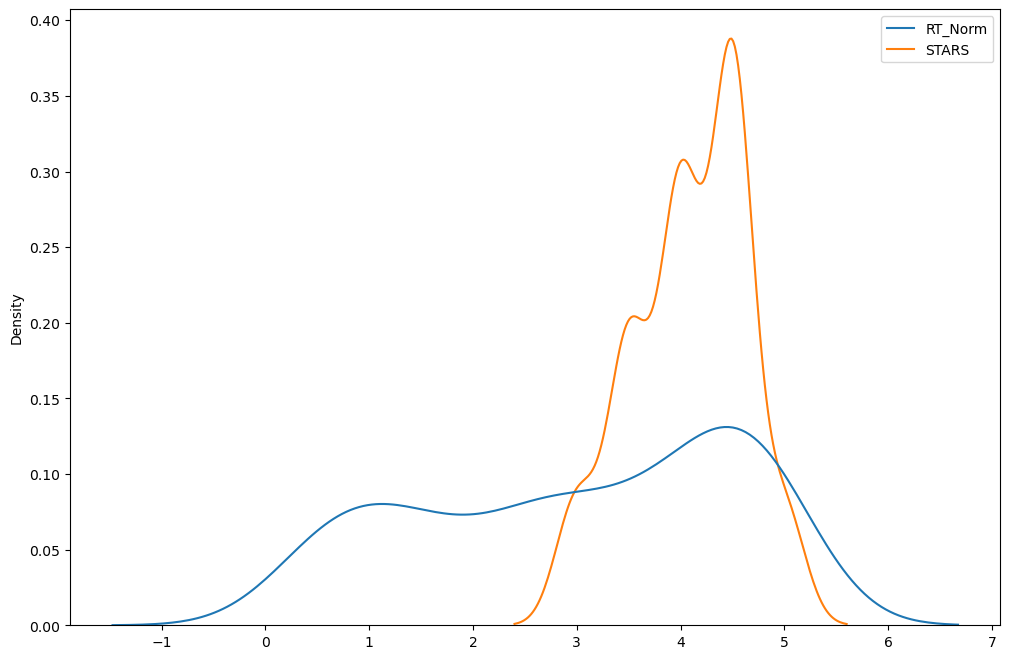

In [30]:
plt.figure(figsize=(12, 8))
sns.kdeplot(data=norm_scores[['RT_Norm', 'STARS']])

The distribution plots suggest that **Fandango's scores are shifted to the right** relative to several competing sources.  
In simple terms, the same films often look more positively rated on Fandango than on Rotten Tomatoes, Metacritic, or IMDb.

## 8. What happens for the lowest-rated films?

In [31]:
norm_scores_films = films[['STARS', 'RATING', 'RT_Norm', 'RTU_Norm', 'MC_Norm', 'MCU_Norm', 'IMDB_Norm', 'FILM']]

In [32]:
norm_scores_films.sort_values('RT_Norm').head(10)

,STARS,RATING,RT_Norm,RTU_Norm,MC_Norm,MCU_Norm,IMDB_Norm,FILM
49,3.5,3.5,0.2,1.8,0.6,1.2,2.2,Paul Blart: Mall Cop 2 (2015)
25,4.5,4.1,0.4,2.3,1.3,2.3,3.0,Taken 3 (2015)
28,3.0,2.7,0.4,1.0,1.4,1.2,2.0,Fantastic Four (2015)
84,4.0,3.9,0.4,2.4,1.4,1.6,3.0,Hitman: Agent 47 (2015)
54,4.0,3.7,0.4,1.8,1.6,1.8,2.4,Hot Pursuit (2015)
50,4.0,3.6,0.5,1.8,1.5,2.8,2.3,The Boy Next Door (2015)
109,3.0,2.9,0.6,1.0,1.8,2.7,2.3,The Vatican Tapes (2015)
88,4.0,3.6,0.6,2.0,1.2,1.2,3.2,The Loft (2015)
87,3.5,3.2,0.6,1.4,1.6,1.9,2.7,Unfinished Business (2015)
83,3.5,3.3,0.6,1.7,1.6,2.5,2.8,Sinister 2 (2015)


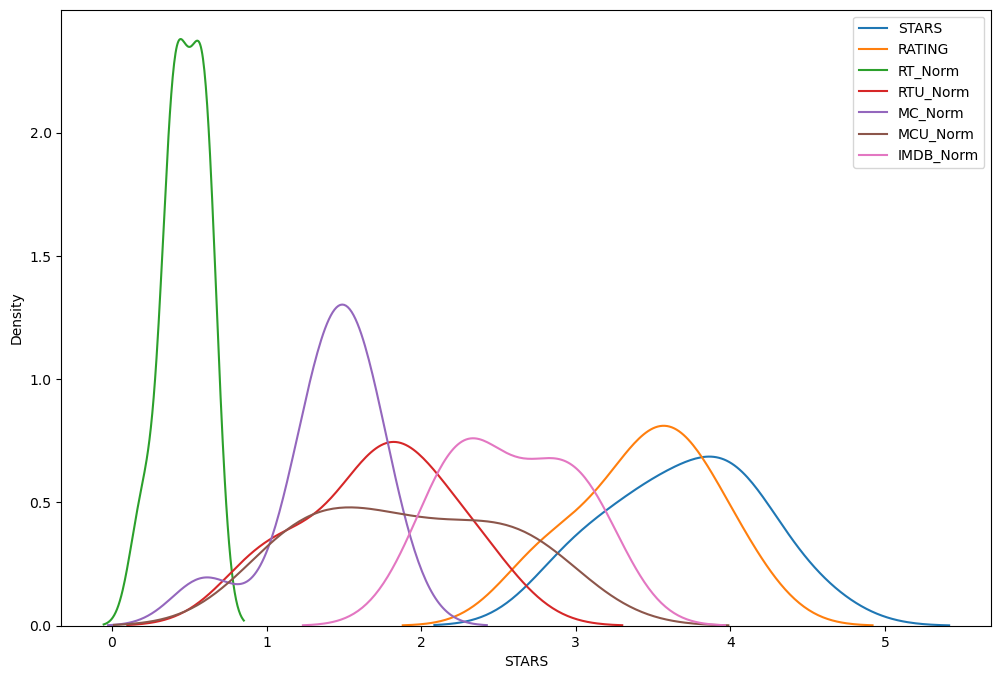

In [33]:
plt.figure(figsize=(12, 8))
for col in norm_scores.columns:
    sns.kdeplot(data=norm_scores.sort_values('RT_Norm')[col].head(10), label=col)
plt.legend()

This is the strongest practical signal in the notebook:  
even for films with very low normalized Rotten Tomatoes scores, Fandango often shows materially higher ratings.

That pattern does not prove intent on its own, but it is **consistent with a systematically more favorable presentation** of movie ratings.

## Final conclusion

### Key findings
- Fandango ratings are concentrated in the higher range.
- The platform's **displayed star values** can appear higher than the underlying numeric rating.
- After normalizing all rating systems to the same scale, Fandango still looks **more generous** than competing platforms.
- The gap becomes especially noticeable among the **lowest-rated movies**, where Fandango often remains relatively positive.

### Business interpretation
From an analytics perspective, this project is a good example of how platform design, incentives, and metric presentation can influence user perception.

### Limitations
- The dataset is historical and limited to a specific period.
- This is an observational analysis, not a causal experiment.
- Results should be interpreted as evidence of a pattern, not absolute proof of motivation.